# People on Banknotes

Whose faces appear on banknotes?

The file `people-on-banknotes.csv` contains data about individuals featured on banknotes from 38 countries. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

It profiles 241 people, detailing their occupations and the year they first appeared on a banknote. Additionally, it includes their year of death — or `NaN` if they were still alive when the dataset was compiled.

Most banknotes were issued after the featured individual’s death. The column `first_death_diff` calculates the difference between the year of their first appearance on a banknote and their year of death (or remains `NaN` if the person was still living at the time of curation).




In [7]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'people-on-banknotes.csv'.

# from google.colab import files
# uploaded = files.upload()

In [8]:
import pandas as pd

df = pd.read_csv('people-on-banknotes.csv')
df

,country,currency,name,gender,occupation,value,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,100,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,100,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,50,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,20,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,10,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,200,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,20,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,100,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,10,2018,1845,173.0,VES


### Quick cleaning

The same person can appear on multiple banknotes. Below we drop the `value` column and remove duplicate people.

In [9]:
df = df.drop(columns=['value'])
df = df.drop_duplicates(subset="name")
df

,country,currency,name,gender,occupation,first_appearance,death,first_death_diff,currency_code
0,Argentina,Argentine Peso,Eva Perón,F,Activist,2012,1952,60.0,ARS
1,Argentina,Argentine Peso,Julio Argentino Roca,M,Head of Gov't,1988,1914,74.0,ARS
2,Argentina,Argentine Peso,Domingo Faustino Sarmiento,M,Head of Gov't,1999,1888,111.0,ARS
3,Argentina,Argentine Peso,Juan Manuel de Rosas,M,Politician,1992,1877,115.0,ARS
4,Argentina,Argentine Peso,Manuel Belgrano,M,Founder,1970,1820,150.0,ARS
...,...,...,...,...,...,...,...,...,...
274,Venezuela,Venezuelan Bolivar,Francisco de Miranda,M,Military,1968,1816,152.0,VES
275,Venezuela,Venezuelan Bolivar,Simón Rodrigues,M,Educator,2007,1854,153.0,VES
276,Venezuela,Venezuelan Bolivar,Ezequiel Zamora,M,Military,2018,1860,158.0,VES
277,Venezuela,Venezuelan Bolivar,Rafael Urdaneta,M,Head of Gov't,2018,1845,173.0,VES


### Project Ideas

- What proportion of individuals featured are male versus female?
	- Hint: Use `value_counts(normalize=True)` to calculate percentages.

- Are writers or politicians more commonly depicted?

- What percentage of featured individuals are musicians?

- What percentage of banknotes were issued before the person’s death?
	- Hint: Look for negative values or NaN in `first_death_diff`.

- Who is the oldest historical figure in the dataset?

- Which countries feature the oldest historical figures on their banknotes?
	- Hint: Group by country and aggregate the year of death using the median. Sort the results.

- What percentage of individuals died at least 100 years before appearing on a banknote?

- Which individuals appeared on a banknote just one year after their death?


#### Calculating the proportion of individuals according to their gender

- df.shape[0]: df.shape return a tuple with two values (rows number, column number) in this assigment we are interested in rows number to use this value as the total of rows and calculate the proportion.

In [78]:
gender_group = df.groupby('gender')
series = gender_group['gender'].value_counts()
df_gender = series.reset_index()

total = df.shape[0] 

df_gender['proportion']= df_gender.eval('count*100/@total').round(2)

df_gender





,gender,count,proportion
0,F,53,21.99
1,M,188,78.01


- Pie chart:

    - autopct: stands for "automatic percentage" is a parameter used by pie chart and it's part of matplotlib library. Automatically calculates the percentage value, handling the math part


Text(0.5, 1.0, 'Proportion by gender')

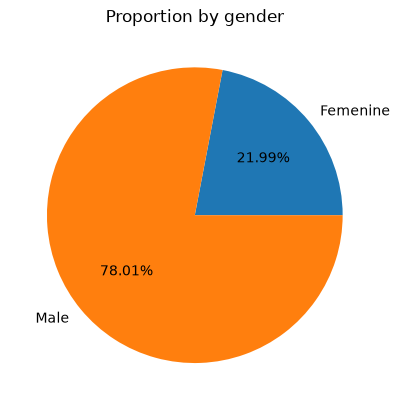

In [71]:
import matplotlib.pyplot as plt

gen_labels = ["Femenine", "Male"]
plt.pie(df_gender['count'],labels=gen_labels, autopct="%1.2f%%")
plt.title("Proportion by gender")

In [86]:
groups = df.groupby('occupation')
groups_df = groups['occupation'].value_counts().reset_index()

occupation_list = ['Writer', 'Politician']
filter_df = groups_df[groups_df['occupation'].isin(occupation_list)]

filter_df


,occupation,count
9,Politician,27
14,Writer,45


From previous result we can see that there are less Politicians than Writer.

#### What percentage of featured individuals are musicians?

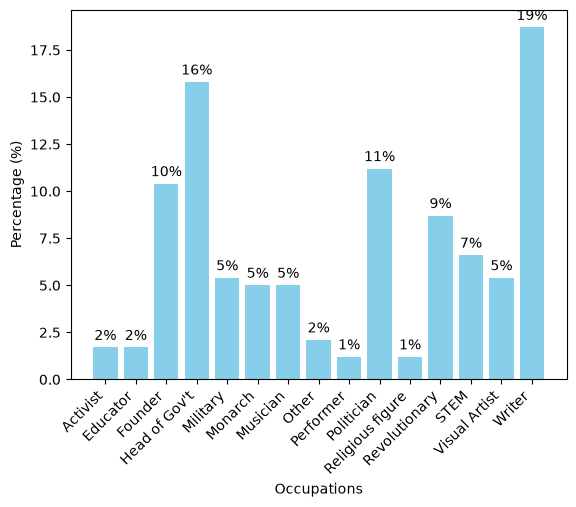

,occupation,count,percentage
0,Activist,4,1.7
1,Educator,4,1.7
2,Founder,25,10.4
3,Head of Gov't,38,15.8
4,Military,13,5.4
5,Monarch,12,5.0
6,Musician,12,5.0
7,Other,5,2.1
8,Performer,3,1.2
9,Politician,27,11.2


In [105]:
groups_df['percentage'] = groups_df.eval('count*100/@total').round(1)


fig,ax=plt.subplots()
bars = ax.bar(groups_df['occupation'], groups_df['percentage'], color= 'skyblue')

ax.bar_label(bars, fmt='%1.0f%%', padding=3)
ax.set_xticks(range(len(groups_df['occupation'])))
ax.set_xticklabels(groups_df['occupation'], rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.xlabel('Occupations')
plt.show()

groups_df


Only 5% of the data provided shows people who are musicians.

#### - What percentage of banknotes were issued before the person’s death?
	- Hint: Look for negative values or NaN in `first_death_diff`.

Explaining the solution:

    - .isna(): returns NaN values that is important for the exercise
    - .shape[0]: shape to get the dimension of the dataframe. Adding [0] returns number of rows.
    

In [196]:
nan_neg_df =df.query('first_death_diff.isna() or first_death_diff < 0').shape[0]

total_rows =df.shape[0]

percentage_nan_neg = round(100*nan_neg_df/total_rows,1)

print(f'The banknotes issued before the person\'s death is {percentage_nan_neg}%')


The banknotes issued before the person's death is 4.6%


#### Who is the oldest historical figure in the dataset?

Hannibal from Tunisia is the oldest historical figure shows in the dataset

In [179]:
df.sort_values('death', ascending= True).head(1)


,country,currency,name,gender,occupation,first_appearance,death,first_death_diff,currency_code
234,Tunisia,Tunisian Dinar,Hannibal,M,Military,2013,-183,2196.0,TND


#### - Which countries feature the oldest historical figures on their banknotes?
	- Hint: Group by country and aggregate the year of death using the median. Sort the results.

First it's important to know the data type in the dataframe. Using .dtypes it will returns the data type per column.

Then, only to be sure that I'm not modifying the original dataframe I create a copy using .copy(). I was concerned about death column because it contents string datatype, but to calculate the median I need numbers.

astype(int) allows cast the datatype of the column and convert the values to integers.



In [ ]:
#Transforming
df.dtypes

copy_df = df.copy()

nonna_values=copy_df.query('death.notna()')
nonna_values['death'] = nonna_values['death'].astype(int)


nonna_values.dtypes

groups_country=nonna_values.groupby('country')['death'].median().reset_index()

groups_country.sort_values('death', ascending=True)


,country,death
29,South Korea,1560.5
31,São Tomé and Príncipe,1779.5
34,Ukraine,1817.5
35,United States,1826.0
3,Bolivia,1839.5
14,Iceland,1845.0
37,Venezuela,1849.5
10,Czech Republic,1869.0
6,Chile,1879.0
0,Argentina,1888.0


#### What percentage of individuals died at least 100 years before appearing on a banknote?

In [189]:
percentage_before_death=len(df.query('first_death_diff >= 100'))*100/(len(df))

print(f'The percentage of people who appeared at least after their death were {round(percentage_before_death,1)}%')

The percentage of people who appeared at least after their death were 33.2%


#### - Which individuals appeared on a banknote just one year after their death?

In [195]:
just_one_year=df.query('first_death_diff == 1')

print(f'{len(just_one_year)} individuals appeared on a banknote just one year after their death.')

4 individuals appeared on a banknote just one year after their death.
